In [1]:
%cd /content
!rm -rf 18_10123154_12523066_CDUTV
!git clone https://github.com/YoungHyyy/18_10123154_12523066_CDUTV
%cd 18_10123154_12523066_CDUTV

import sys, sklearn, numpy, pandas
sys.path.insert(0, "ai-models/src")
print("sklearn", sklearn.__version__, "| numpy", numpy.__version__, "| pandas", pandas.__version__)

/content
Cloning into '18_10123154_12523066_CDUTV'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 54 (delta 15), reused 47 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 1.75 MiB | 6.07 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/18_10123154_12523066_CDUTV
sklearn 1.6.1 | numpy 2.1.3 | pandas 2.2.3


In [2]:
import warnings; warnings.filterwarnings("ignore")
from preprocess import load_data, split, ROOT
from train import run_experiments
import evaluate as ev

X, y = load_data()
X_train, X_test, y_train, y_test = split(X, y)

results, fitted = run_experiments(X_train, X_test, y_train, y_test)
print("\nĐã có", len(fitted), "model:", list(fitted))

>>> Logistic Regression (baseline)
>>> KNN
>>> SVM (RBF)
>>> Decision Tree
>>> Random Forest

Đã có 5 model: ['Logistic Regression (baseline)', 'KNN', 'SVM (RBF)', 'Decision Tree', 'Random Forest']


In [3]:
results[["model", "test_recall", "test_precision", "test_f1", "test_roc_auc"]]

,model,test_recall,test_precision,test_f1,test_roc_auc
0,Logistic Regression (baseline),0.9762,1.0000,0.9880,0.9977
1,KNN,0.8571,0.9730,0.9114,0.9825
2,SVM (RBF),0.9762,1.0000,0.9880,0.9970
3,Decision Tree,0.8333,0.8974,0.8642,0.9076
4,Random Forest,0.9286,1.0000,0.9630,0.9965


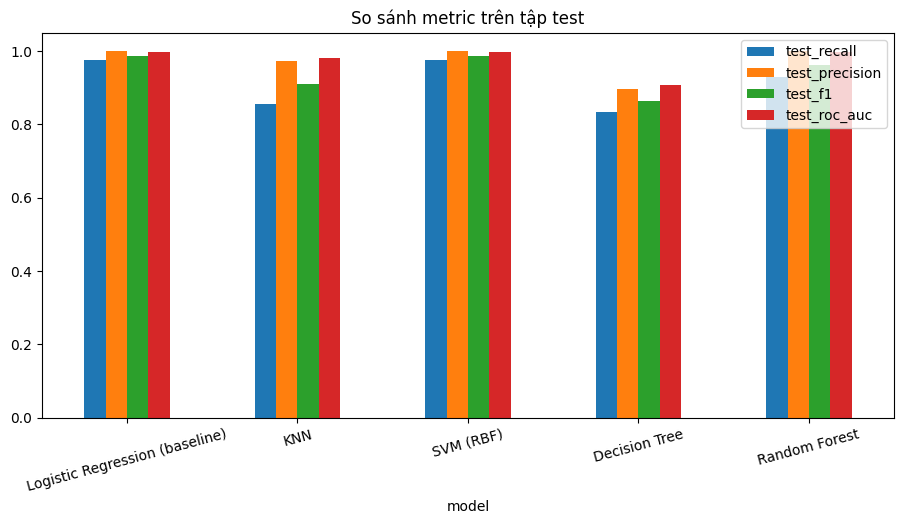

In [4]:
ev.plot_metric_comparison(results)

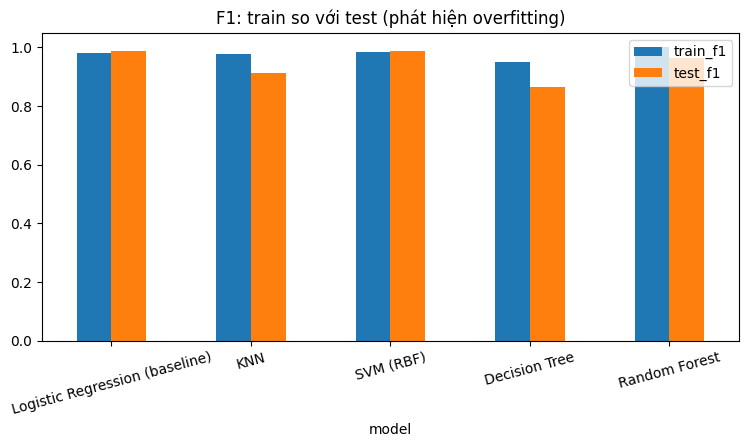

In [5]:
ev.plot_overfit(results)

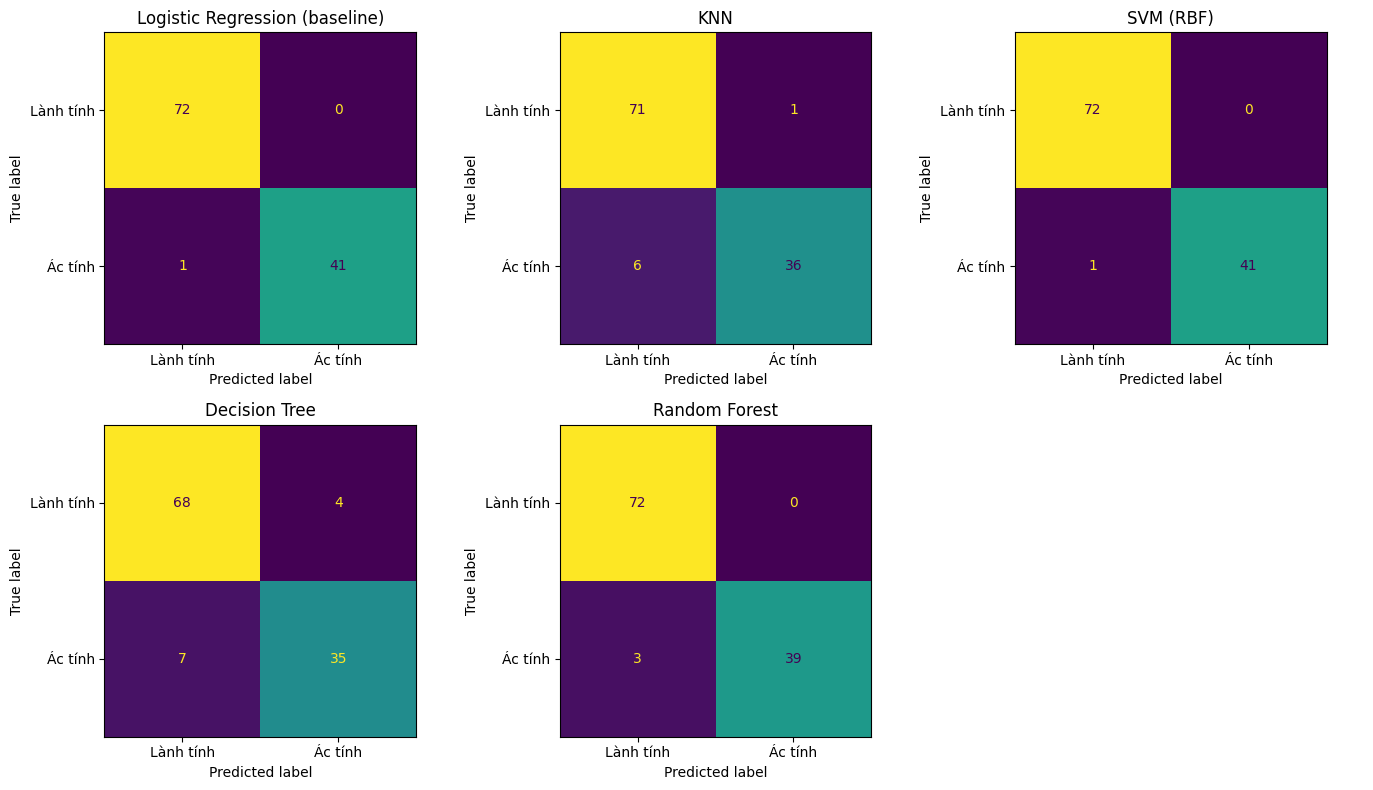

In [6]:
ev.plot_confusion_matrices(fitted, X_test, y_test)

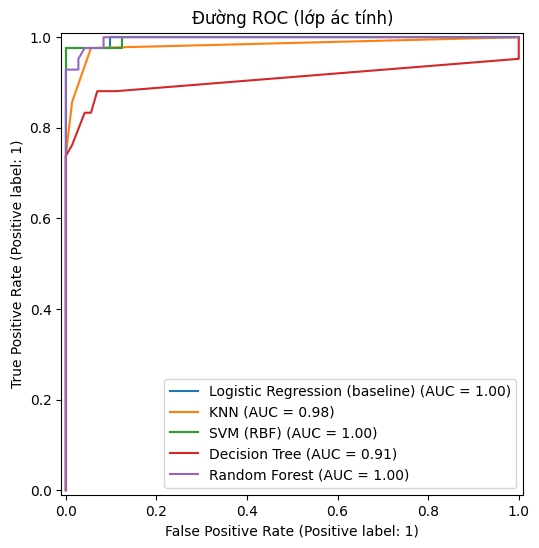

In [7]:
ev.plot_roc(fitted, X_test, y_test)

In [8]:
from sklearn.metrics import confusion_matrix

print(f"Tổng mẫu test: {len(y_test)} | Ca ác tính: {int(y_test.sum())} | Ca lành tính: {int((y_test == 0).sum())}\n")
for name, m in fitted.items():
    tn, fp, fn, tp = confusion_matrix(y_test, m.predict(X_test)).ravel()
    print(f"{name:32s} bỏ sót ác tính (FN)={fn:2d} | báo nhầm (FP)={fp:2d} | đúng={tp+tn}/{len(y_test)}")

Tổng mẫu test: 114 | Ca ác tính: 42 | Ca lành tính: 72

Logistic Regression (baseline)   bỏ sót ác tính (FN)= 1 | báo nhầm (FP)= 0 | đúng=113/114
KNN                              bỏ sót ác tính (FN)= 6 | báo nhầm (FP)= 1 | đúng=107/114
SVM (RBF)                        bỏ sót ác tính (FN)= 1 | báo nhầm (FP)= 0 | đúng=113/114
Decision Tree                    bỏ sót ác tính (FN)= 7 | báo nhầm (FP)= 4 | đúng=103/114
Random Forest                    bỏ sót ác tính (FN)= 3 | báo nhầm (FP)= 0 | đúng=111/114


In [9]:
import shutil
from google.colab import files

shutil.make_archive("/content/model_figures", "zip", str(ROOT / "docs" / "figures"))
files.download("/content/model_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>